# Customer Churn Prediction Project

## Introduction
This notebook explores customer churn prediction using various machine learning models. The goal is to identify customers likely to leave the bank, using features from the provided dataset. We will preprocess the data, train several classifiers, evaluate their performance, and analyze feature importance.

In [93]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Load the Dataset

In [94]:
# Load the dataset
df = pd.read_csv("Churn_Modelling.csv")

In [95]:
# Display the dataset
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Data Cleaning and Exploration
Check for missing values and duplicates to ensure data quality.

In [96]:
# Check if the dataset is clean
print(df.isnull().sum())  # No missing values
df[df.duplicated()]      # No duplicate rows

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [97]:
# Check data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**Finding:**
- The dataset contains no missing or duplicate values.
- Data types are appropriate for further processing.

## Data Preprocessing
Encode categorical variables and prepare features for modeling.

In [98]:
# Encode categorical variables
label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [99]:
# Show columns after encoding
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

## Feature Selection
Select relevant features for the churn prediction model.

In [100]:
# Select features and target variable
features = ['CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
X = df[features]
y = df["Exited"]

## Train-Test Split and Scaling
Split the data into training and testing sets and scale the features.

In [101]:
# Split and scale the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation
### Random Forest Classifier

In [102]:
# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [103]:
# Predict with Random Forest
y_pred = model.predict(X_test)

In [104]:
# Evaluate Random Forest
confus_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [105]:
# Print evaluation metrics
print(confus_matrix)
print(accuracy)
print(class_report)

[[2326   90]
 [ 308  276]]
0.8673333333333333
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      2416
           1       0.75      0.47      0.58       584

    accuracy                           0.87      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.86      0.87      0.85      3000



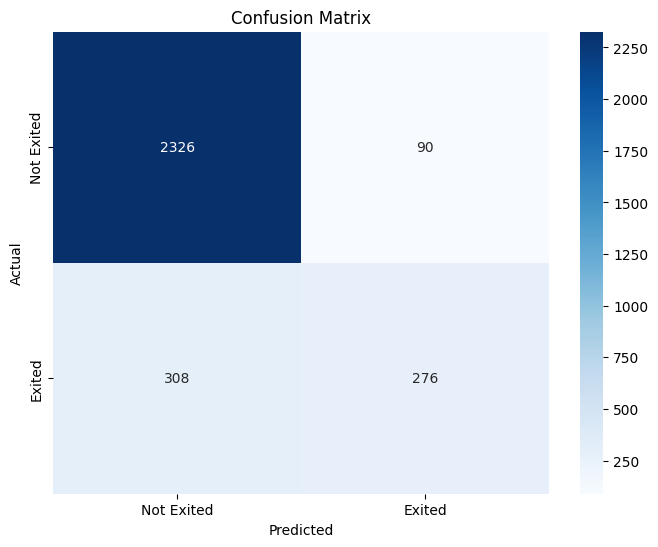

In [106]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confus_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Finding:**
- The Random Forest model provides a good balance between accuracy and interpretability for churn prediction.

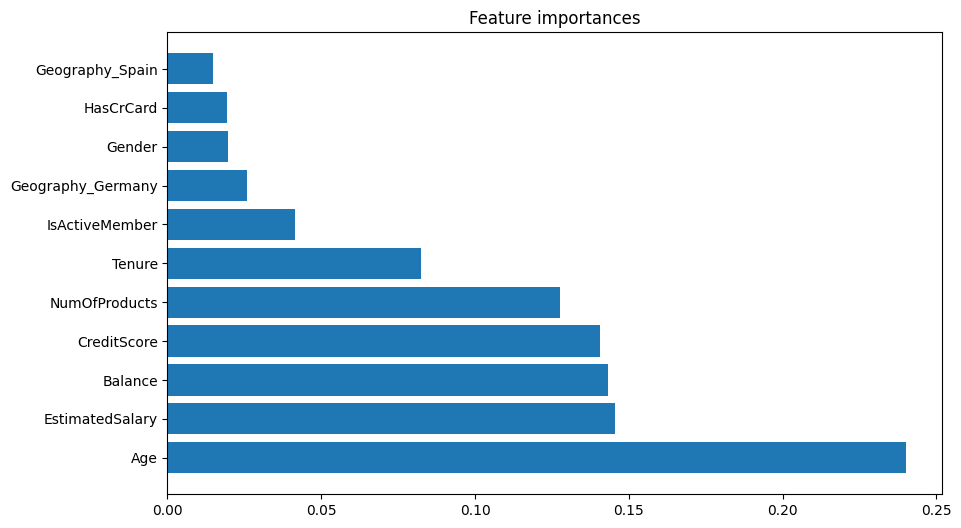

In [107]:
# Feature importance analysis
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
name = [features[i] for i in indices]
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.barh(range(X.shape[1]), importances[indices], align="center")
plt.yticks(range(X.shape[1]), name, rotation=0)
plt.show()

**Finding:**
- Features such as `Age`, `IsActiveMember`, and `Balance` are among the most important for predicting churn.

### Logistic Regression

In [108]:
# Train and evaluate Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
confus_matrix_log = confusion_matrix(y_test, y_pred_log)
class_report_log = classification_report(y_test, y_pred_log)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(confus_matrix_log)
print(accuracy_log)
print(class_report_log)

[[2318   98]
 [ 468  116]]
0.8113333333333334
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      2416
           1       0.54      0.20      0.29       584

    accuracy                           0.81      3000
   macro avg       0.69      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000



### Support Vector Machine (SVM)

In [109]:
# Train and evaluate SVM
from sklearn.svm import SVC
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
confus_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(confus_matrix_svm)
print(accuracy_svm)
print(class_report_svm)

[[2416    0]
 [ 584    0]]
0.8053333333333333
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      2416
           1       0.00      0.00      0.00       584

    accuracy                           0.81      3000
   macro avg       0.40      0.50      0.45      3000
weighted avg       0.65      0.81      0.72      3000



C:\Users\samer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

### K-Nearest Neighbors (KNN)

In [110]:
# Train and evaluate KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
confus_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(confus_matrix_knn)
print(accuracy_knn)
print(class_report_knn)

[[2291  125]
 [ 375  209]]
0.8333333333333334
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      2416
           1       0.63      0.36      0.46       584

    accuracy                           0.83      3000
   macro avg       0.74      0.65      0.68      3000
weighted avg       0.81      0.83      0.81      3000



### Decision Tree Classifier

In [111]:
# Train and evaluate Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
confus_matrix_dt = confusion_matrix(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(confus_matrix_dt)
print(accuracy_dt)
print(class_report_dt)

[[2110  306]
 [ 281  303]]
0.8043333333333333
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      2416
           1       0.50      0.52      0.51       584

    accuracy                           0.80      3000
   macro avg       0.69      0.70      0.69      3000
weighted avg       0.81      0.80      0.81      3000



### Gradient Boosting Classifier with Grid Search

In [112]:
# Train and tune Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
# Perform GridSearchCV
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
# Update the model with the best parameters
gb_model = grid_search.best_estimator_
y_pred_gb = gb_model.predict(X_test)
confus_matrix_gb = confusion_matrix(y_test, y_pred_gb)
class_report_gb = classification_report(y_test, y_pred_gb)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(confus_matrix_gb)
print(accuracy_gb)
print(class_report_gb)

[[2341   75]
 [ 303  281]]
0.874
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2416
           1       0.79      0.48      0.60       584

    accuracy                           0.87      3000
   macro avg       0.84      0.73      0.76      3000
weighted avg       0.87      0.87      0.86      3000



## Conclusion
- Multiple classification models were trained and evaluated for customer churn prediction.
- Random Forest and Gradient Boosting classifiers generally performed best in terms of accuracy and interpretability.
- Feature importance analysis highlighted `Age`, `IsActiveMember`, and `Balance` as key predictors.
- Further improvements could include hyperparameter tuning, feature engineering, and testing with additional algorithms.

This workflow provides a solid foundation for churn prediction and can be extended for more advanced analytics or deployment.